# Weather Data EDA

This notebook explores the raw Toronto weather file used in the project.  
It highlights data quality, seasonality, hourly temperature structure, and a few key weather relationships

In [54]:
# Imports, paths, and plotting style
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="white", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 320
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.facecolor"] = "#ffffff"
plt.rcParams["figure.facecolor"] = "#ffffff"
plt.rcParams["grid.color"] = "#e5e7eb"
plt.rcParams["grid.alpha"] = 0.65
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "data").exists() and (p / "results").exists():
            return p
    return start

NOTEBOOK_DIR = Path.cwd()
REPO_DIR = find_repo_root(NOTEBOOK_DIR)
RAW_DIR = REPO_DIR / "data" / "data_raw"
FIG_DIR = REPO_DIR / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FILE_PATH = RAW_DIR / "weather raw 23-25.xlsx"

print("Repo root:", REPO_DIR)
print("Raw file:", FILE_PATH)
print("Figure folder:", FIG_DIR)

def save_and_show(fig, fig_name: str):
    fig.patch.set_facecolor("white")
    out = FIG_DIR / f"{fig_name}.png"
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    print("Saved:", out)
    plt.show()
    plt.close(fig)

def count_fmt(x, pos):
    return f"{int(x):,}"

count_formatter = FuncFormatter(count_fmt)

GREEN = "#22c55e"
LIGHT_GREEN = "#bbf7d0"
YELLOW = "#facc15"
ORANGE = "#fb923c"
RED = "#ef4444"
DARK_RED = "#b91c1c"
BLUE = "#2563eb"
TEAL = "#0f766e"
SLATE = "#475569"

WEATHER_HEATMAP = LinearSegmentedColormap.from_list(
    "weather_hour_temp",
    ["#f0fdf4", "#86efac", "#facc15", "#fb923c", "#ef4444"]
)

CORR_CMAP = LinearSegmentedColormap.from_list(
    "corr_div",
    ["#ef4444", "#fb923c", "#fef3c7", "#bbf7d0", "#22c55e"]
)

Repo root: /Users/singye/Desktop/toronto-prediction-collision
Raw file: /Users/singye/Desktop/toronto-prediction-collision/data/data_raw/weather raw 23-25.xlsx
Figure folder: /Users/singye/Desktop/toronto-prediction-collision/results/figures


## Load and prepare the raw weather file

In [55]:
df = pd.read_excel(FILE_PATH, engine="openpyxl")
print("Shape:", df.shape)
print("Columns:", len(df.columns))
display(df.head())

Shape: (34097, 22)
Columns: 22


,DMY,Time,pressure_station,pressure_sea,wind_dir,wind_dir_10s,wind_speed,relative_humidity,dew_point,temperature,...,cloud_cover_8,rain,snow,snow_on_ground,max_uv_forecast,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,2025-12-31,23.0,98.10,100.25,NW,31.0,34.0,58.0,-15.9,-9.0,...,1.0,0.0,1.6,2.0,1.0,NaN,NaN,NaN,NaT,NaN
1,2025-12-31,22.0,98.00,100.15,NW,31.0,40.0,61.0,-14.1,-7.8,...,1.0,0.0,1.6,2.0,1.0,NaN,NaN,NaN,NaT,NaN
2,2025-12-31,21.0,97.90,100.05,NW,32.0,41.0,69.0,-11.7,-7.0,...,7.0,0.0,1.6,2.0,1.0,NaN,NaN,NaN,NaT,NaN
3,2025-12-31,20.0,97.81,99.95,NW,31.0,47.0,80.0,-8.4,-5.5,...,3.0,0.0,1.6,2.0,1.0,NaN,NaN,NaN,NaT,NaN
4,2025-12-31,19.0,97.75,99.89,SW,23.0,19.0,86.0,-7.1,-5.1,...,8.0,0.0,1.6,2.0,1.0,NaN,NaN,NaN,NaT,NaN


In [56]:
# Clean the working frame and build a timestamp column
eda = df.copy()

if "DMY" in eda.columns:
    eda["DMY"] = pd.to_datetime(eda["DMY"], errors="coerce")

if "Time" in eda.columns:
    eda["Time"] = pd.to_numeric(eda["Time"], errors="coerce").clip(lower=0, upper=23)

if {"DMY", "Time"}.issubset(eda.columns):
    eda["weather_datetime"] = eda["DMY"].dt.floor("D") + pd.to_timedelta(eda["Time"].fillna(0), unit="h")
    eda["month"] = eda["weather_datetime"].dt.month
    eda["month_name"] = eda["weather_datetime"].dt.month_name()
    eda["month_period"] = eda["weather_datetime"].dt.to_period("M").dt.to_timestamp()
    eda["hour"] = eda["weather_datetime"].dt.hour
    eda["year"] = eda["weather_datetime"].dt.year

# Remove empty helper columns and unnamed fields from plotting
drop_cols = []
for c in eda.columns:
    c_str = str(c).strip()
    if re.match(r"^Unnamed", c_str, flags=re.IGNORECASE):
        drop_cols.append(c)
    elif c_str == "":
        drop_cols.append(c)

eda_plot = eda.drop(columns=drop_cols, errors="ignore").copy()

candidate_num = [
    "temperature", "dew_point", "wind_speed", "pressure_station", "pressure_sea",
    "relative_humidity", "visibility", "rain", "snow", "snow_on_ground",
    "cloud_cover_8", "windchill", "max_uv_forecast"
]
numeric_cols = [c for c in candidate_num if c in eda_plot.columns]
for c in numeric_cols:
    eda_plot[c] = pd.to_numeric(eda_plot[c], errors="coerce")

display(eda_plot.head())

,DMY,Time,pressure_station,pressure_sea,wind_dir,wind_dir_10s,wind_speed,relative_humidity,dew_point,temperature,...,rain,snow,snow_on_ground,max_uv_forecast,weather_datetime,month,month_name,month_period,hour,year
0,2025-12-31,23.0,98.10,100.25,NW,31.0,34.0,58.0,-15.9,-9.0,...,0.0,1.6,2.0,1.0,2025-12-31 23:00:00,12.0,December,2025-12-01,23.0,2025.0
1,2025-12-31,22.0,98.00,100.15,NW,31.0,40.0,61.0,-14.1,-7.8,...,0.0,1.6,2.0,1.0,2025-12-31 22:00:00,12.0,December,2025-12-01,22.0,2025.0
2,2025-12-31,21.0,97.90,100.05,NW,32.0,41.0,69.0,-11.7,-7.0,...,0.0,1.6,2.0,1.0,2025-12-31 21:00:00,12.0,December,2025-12-01,21.0,2025.0
3,2025-12-31,20.0,97.81,99.95,NW,31.0,47.0,80.0,-8.4,-5.5,...,0.0,1.6,2.0,1.0,2025-12-31 20:00:00,12.0,December,2025-12-01,20.0,2025.0
4,2025-12-31,19.0,97.75,99.89,SW,23.0,19.0,86.0,-7.1,-5.1,...,0.0,1.6,2.0,1.0,2025-12-31 19:00:00,12.0,December,2025-12-01,19.0,2025.0


## Data quality snapshot
The first look focuses on missingness and a few simple validity checks for the core weather measurements.

,check,count
0,relative_humidity outside 0-100,0
1,cloud_cover_8 outside 0-8,0
2,visibility missing,7794
3,wind_speed missing,7794
4,rain missing,7793
5,snow missing,7793
6,snow_on_ground missing,7793
7,temperature missing,7796
8,dew_point missing,7796


Saved: /Users/singye/Desktop/toronto-prediction-collision/results/figures/weather_missingness_top20_styled.png


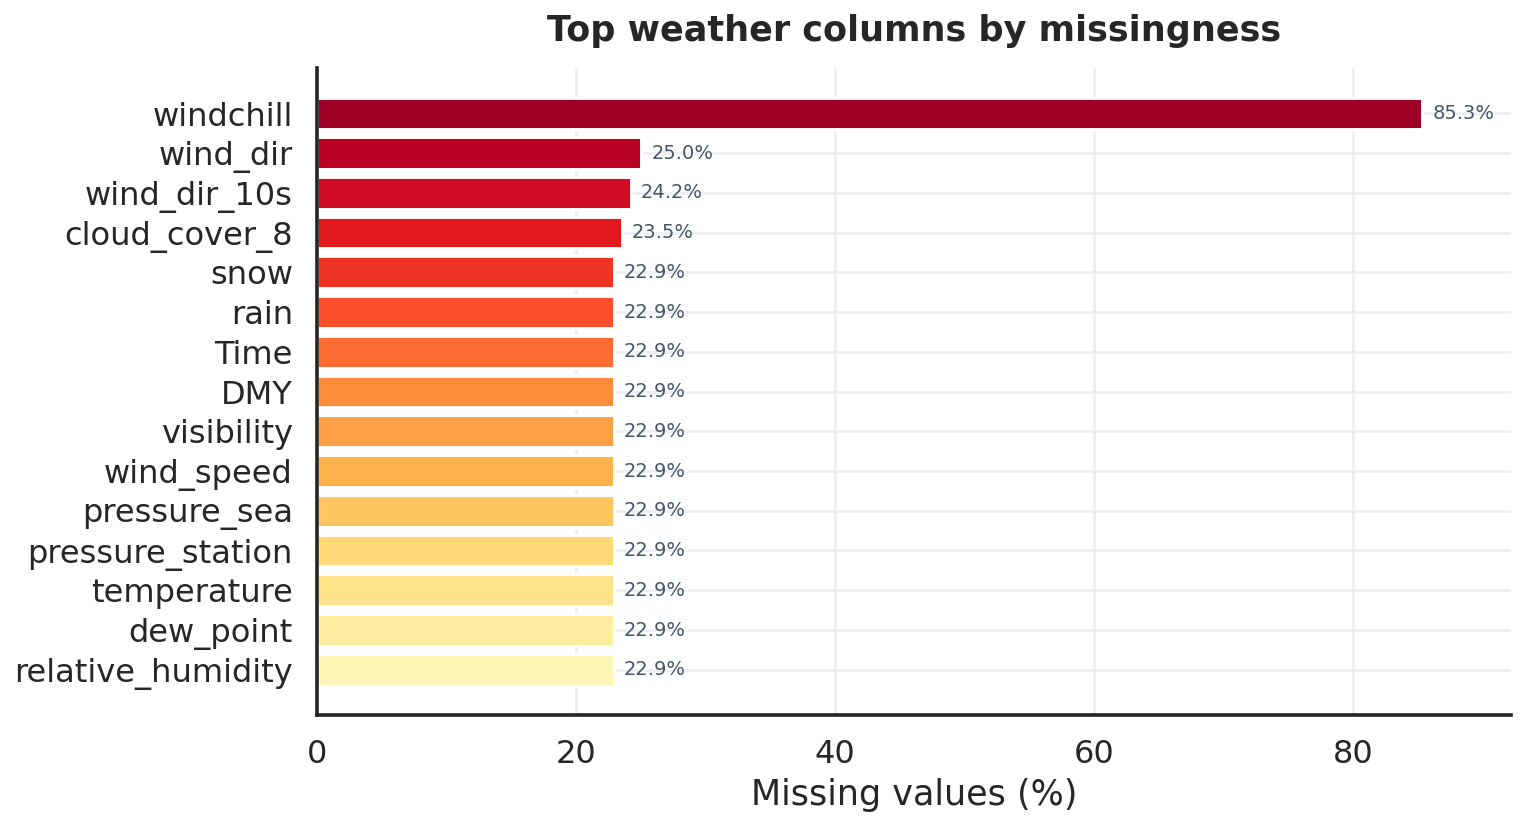

In [57]:
missing = (
    pd.DataFrame({
        "column": eda_plot.columns,
        "missing_count": eda_plot.isna().sum().values,
        "missing_pct": (eda_plot.isna().mean().values * 100).round(1),
    })
    .sort_values(["missing_pct", "missing_count"], ascending=False)
    .reset_index(drop=True)
)

checks = {}
if "relative_humidity" in eda_plot.columns:
    checks["relative_humidity outside 0-100"] = int(((eda_plot["relative_humidity"] < 0) | (eda_plot["relative_humidity"] > 100)).sum())
if "cloud_cover_8" in eda_plot.columns:
    checks["cloud_cover_8 outside 0-8"] = int(((eda_plot["cloud_cover_8"] < 0) | (eda_plot["cloud_cover_8"] > 8)).sum())
for c in ["visibility", "wind_speed", "rain", "snow", "snow_on_ground", "temperature", "dew_point"]:
    if c in eda_plot.columns:
        checks[f"{c} missing"] = int(eda_plot[c].isna().sum())

quality_df = pd.DataFrame(checks.items(), columns=["check", "count"])
display(quality_df)

miss_plot = missing.query("missing_pct > 0").head(15).sort_values("missing_pct", ascending=True)
if len(miss_plot):
    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(
        miss_plot["column"],
        miss_plot["missing_pct"],
        color=sns.color_palette("YlOrRd", n_colors=len(miss_plot))
    )
    ax.set_title("Top weather columns by missingness", pad=14)
    ax.set_xlabel("Missing values (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, max(5, miss_plot["missing_pct"].max() * 1.08))

    for bar, val in zip(bars, miss_plot["missing_pct"]):
        ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=10, color=SLATE)

    ax.spines[["top", "right"]].set_visible(False)
    save_and_show(fig, "weather_missingness_top20_styled")
else:
    print("No missing values to plot.")

## Seasonal structure
These visuals summarize how the core weather variables change across months and hours.

Saved: /Users/singye/Desktop/toronto-prediction-collision/results/figures/weather_monthly_trends_styled.png


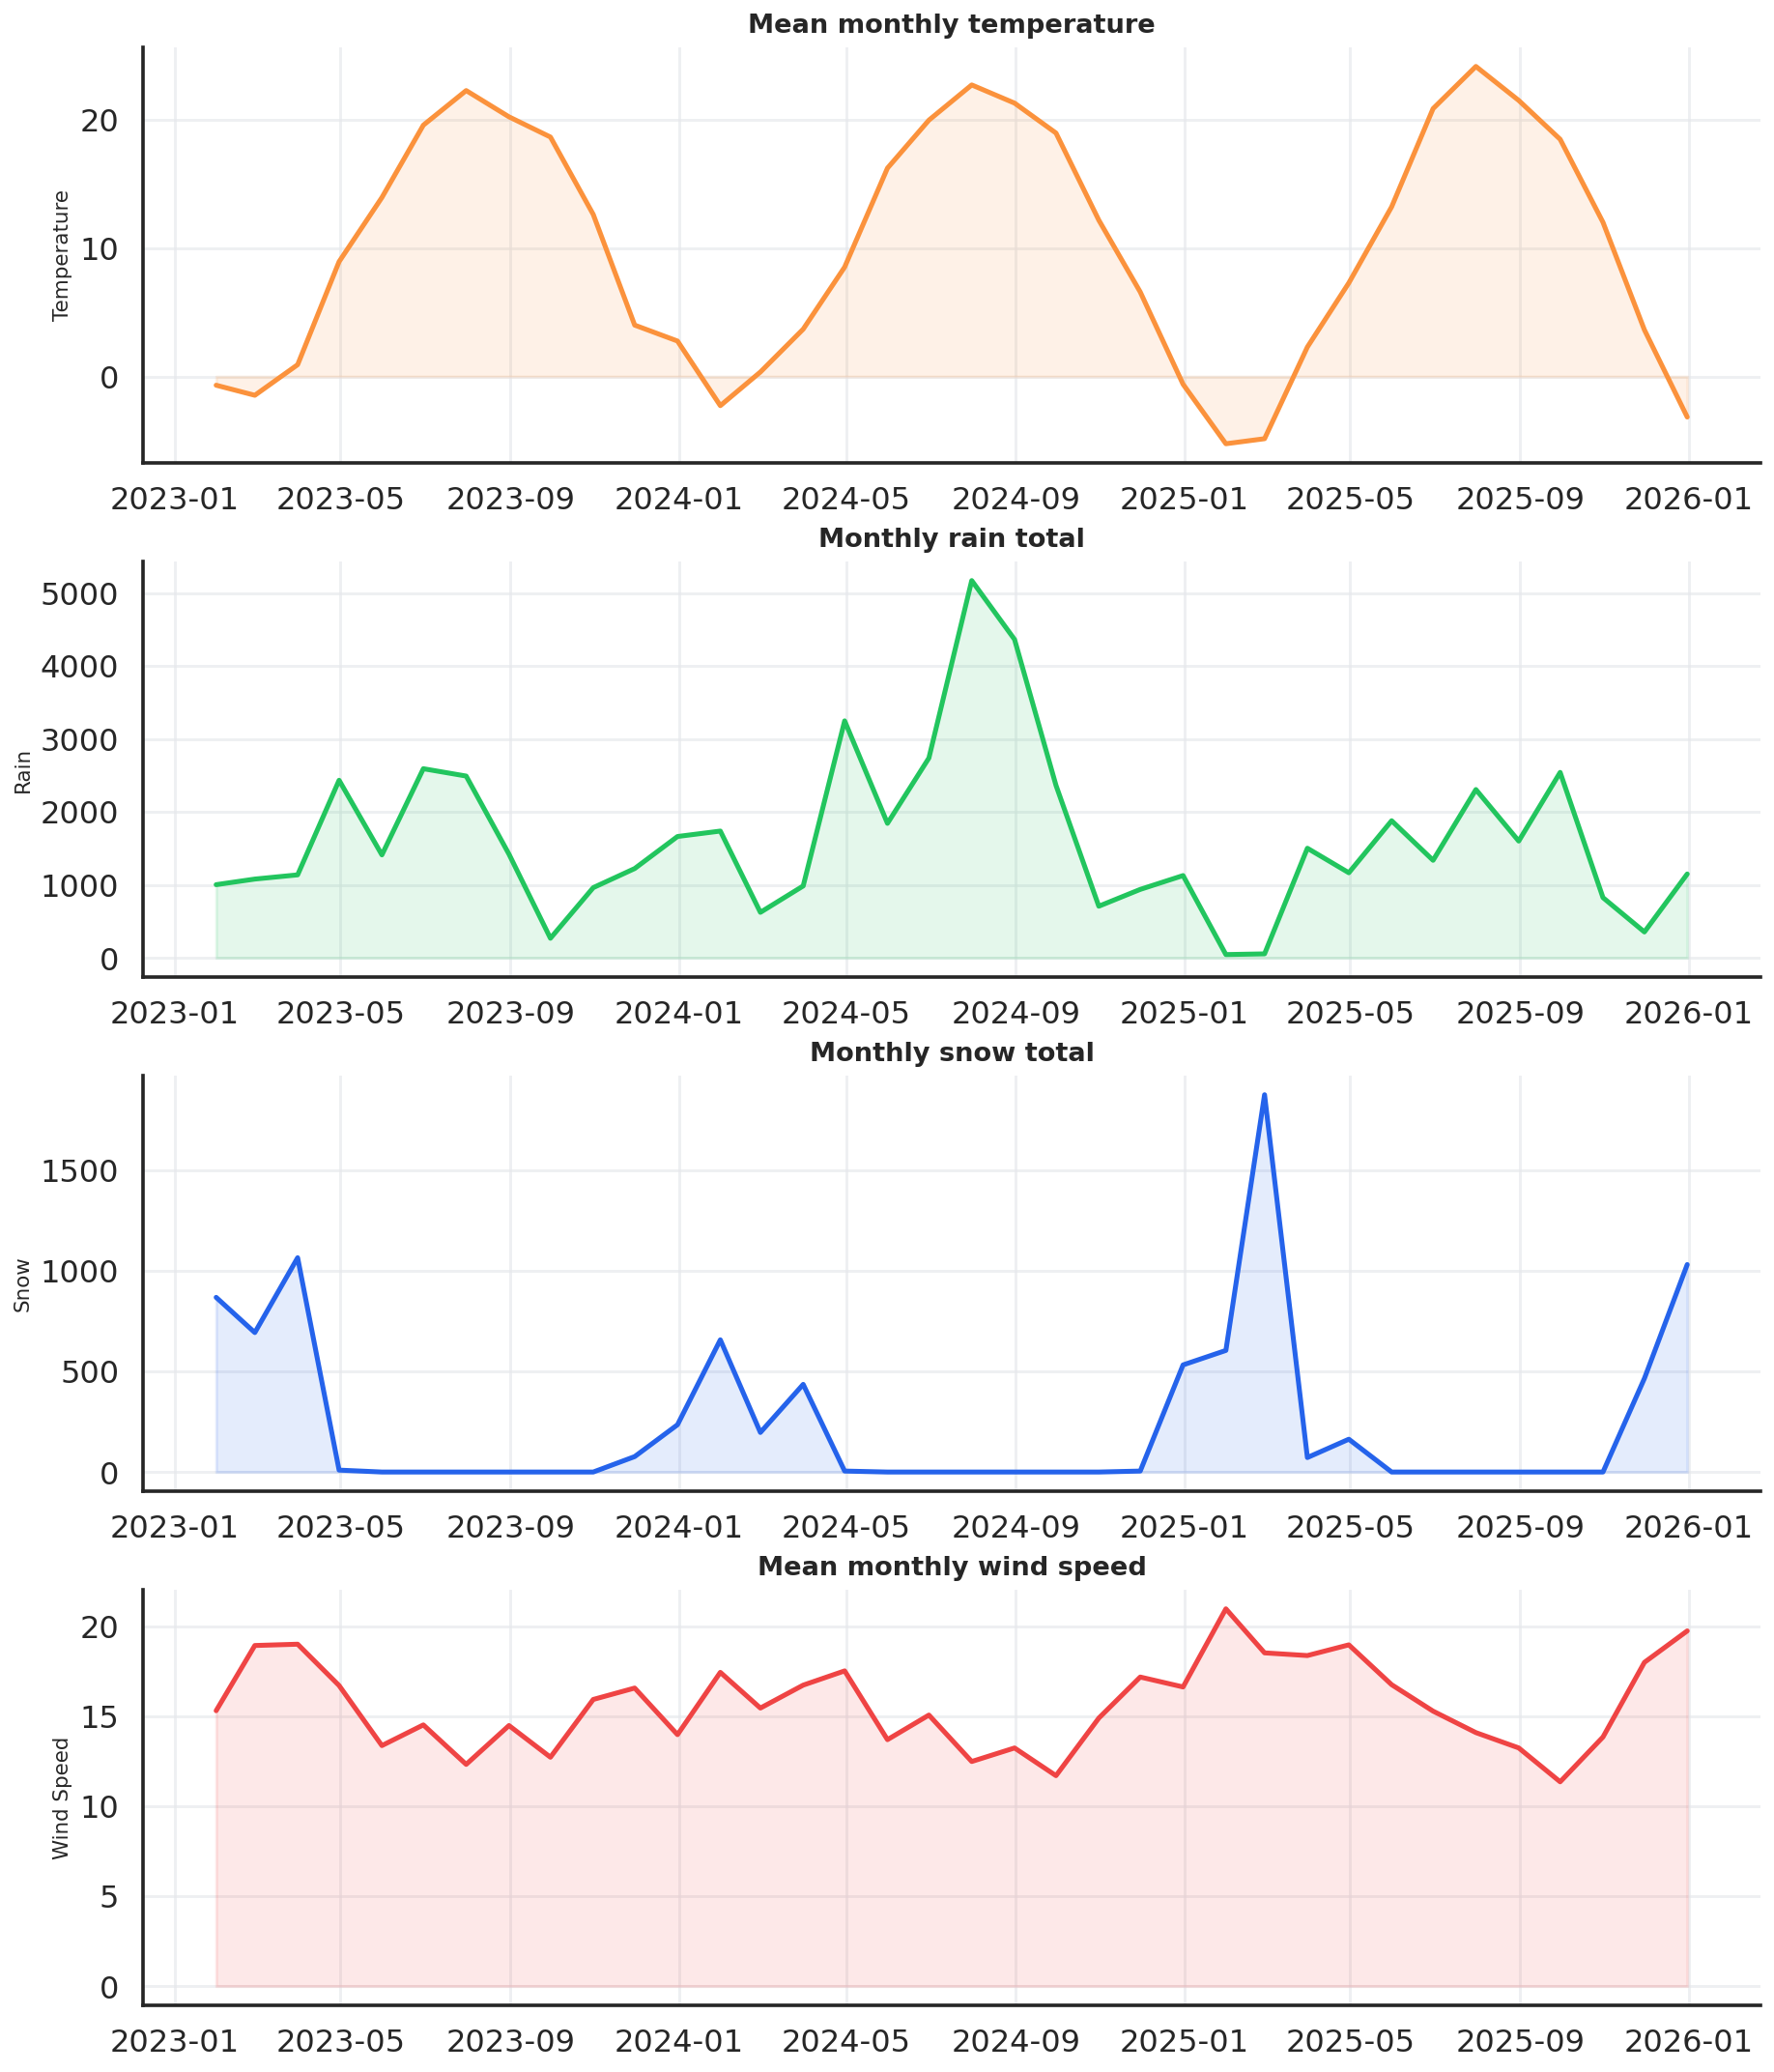

In [58]:
trend_specs = [
    ("temperature", "Mean monthly temperature", ORANGE, "mean"),
    ("rain", "Monthly rain total", GREEN, "sum"),
    ("snow", "Monthly snow total", BLUE, "sum"),
    ("wind_speed", "Mean monthly wind speed", RED, "mean"),
]

available_specs = [spec for spec in trend_specs if spec[0] in eda_plot.columns]

if available_specs and "weather_datetime" in eda_plot.columns:
    fig, axes = plt.subplots(len(available_specs), 1, figsize=(13, 3.8 * len(available_specs)), constrained_layout=True)
    if len(available_specs) == 1:
        axes = [axes]

    for ax, (col, title, color, agg) in zip(axes, available_specs):
        monthly = (
            eda_plot
            .set_index("weather_datetime")[col]
            .resample("M")
            .agg(agg)
            .reset_index()
        )
        ax.plot(monthly["weather_datetime"], monthly[col], color=color, linewidth=2.6)
        ax.fill_between(monthly["weather_datetime"], monthly[col], color=color, alpha=0.12)
        ax.set_title(title, pad=8, fontsize=14)
        ax.set_xlabel("")
        ax.set_ylabel(col.replace("_", " ").title(), fontsize=11)
        ax.spines[["top", "right"]].set_visible(False)

    save_and_show(fig, "weather_monthly_trends_styled")
else:
    print("Monthly trend fields are not available.")

Saved: /Users/singye/Desktop/toronto-prediction-collision/results/figures/weather_month_hour_heatmap_styled.png


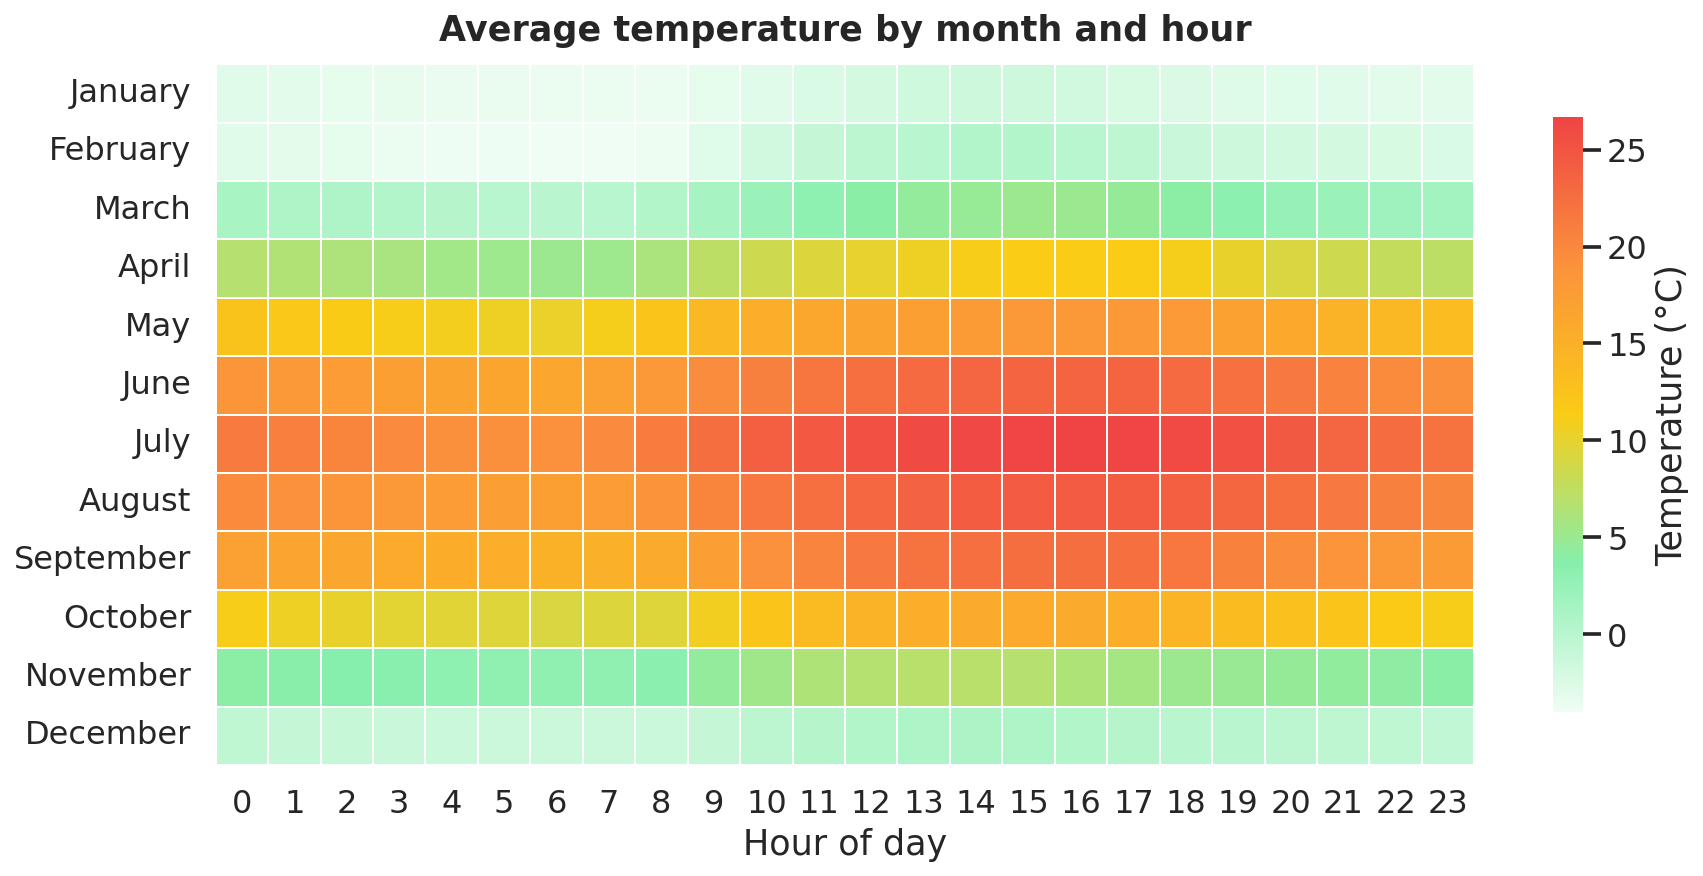

In [59]:
if {"weather_datetime", "hour", "temperature"}.issubset(eda_plot.columns):
    month_order = [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ]

    heat = (
        eda_plot.groupby([eda_plot["weather_datetime"].dt.month_name(), "hour"])["temperature"]
        .mean()
        .unstack(fill_value=np.nan)
        .reindex(index=month_order, columns=range(24))
    )

    fig, ax = plt.subplots(figsize=(14.5, 6.5))
    sns.heatmap(
        heat,
        cmap=WEATHER_HEATMAP,
        ax=ax,
        linewidths=0.15,
        linecolor="white",
        cbar_kws={"label": "Temperature (°C)", "shrink": 0.85}
    )
    ax.set_title("Average temperature by month and hour", pad=12)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("")
    ax.tick_params(axis="y", rotation=0)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    save_and_show(fig, "weather_month_hour_heatmap_styled")
else:
    print("Temperature heatmap fields are not available.")

## Distributions and relationships


Saved: /Users/singye/Desktop/toronto-prediction-collision/results/figures/weather_numeric_distributions_styled.png


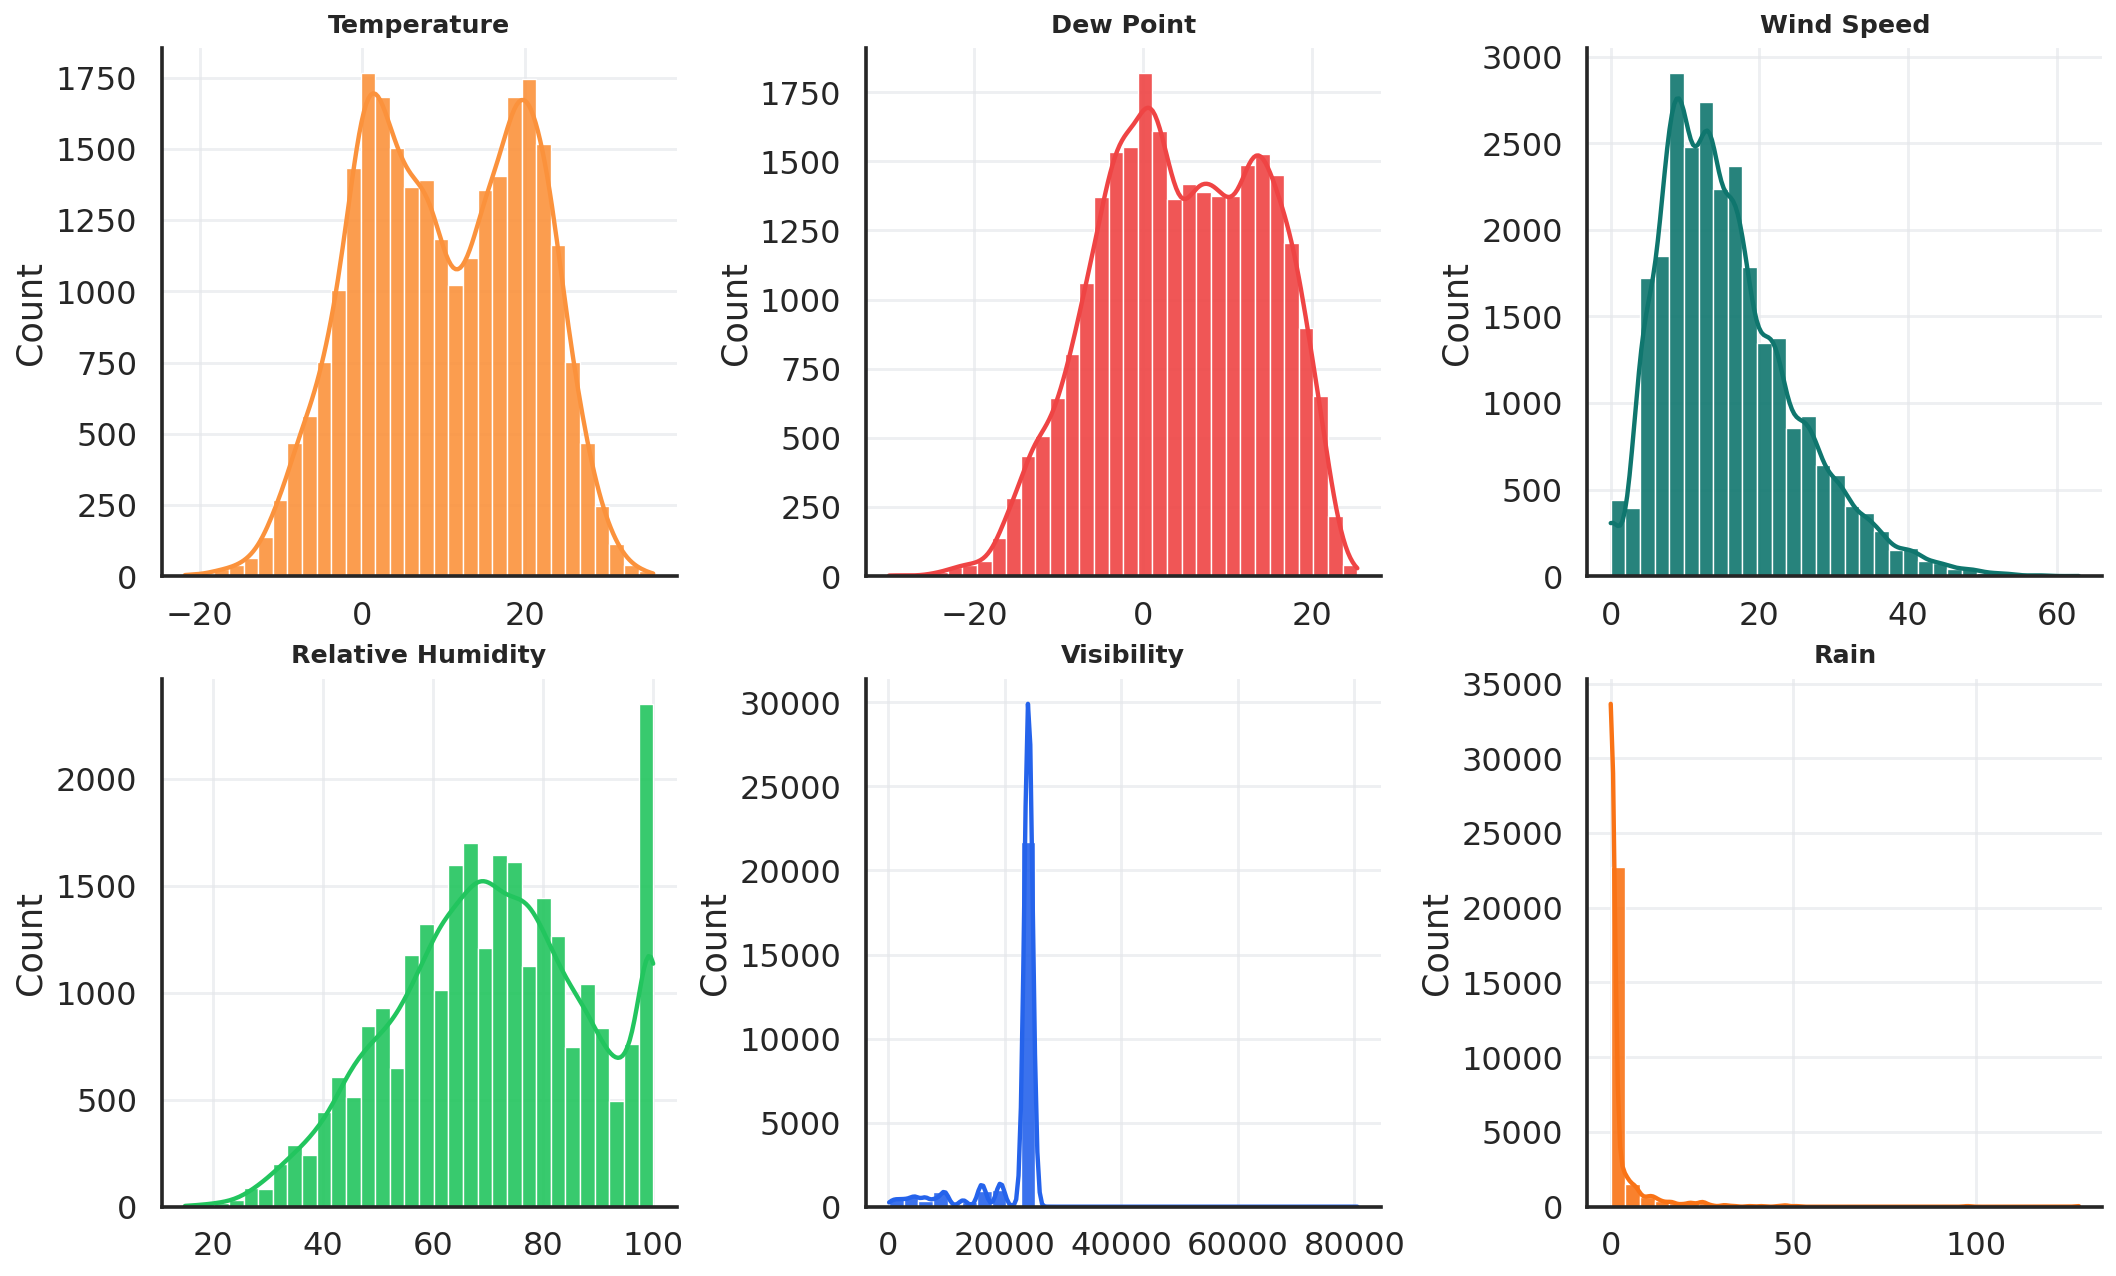

In [60]:
dist_cols = [c for c in ["temperature", "dew_point", "wind_speed", "relative_humidity", "visibility", "rain"] if c in eda_plot.columns]

if dist_cols:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
    axes = axes.ravel()

    palette = [ORANGE, RED, TEAL, GREEN, BLUE, "#f97316"]
    for ax, col, color in zip(axes, dist_cols, palette):
        s = eda_plot[col].dropna()
        sns.histplot(s, bins=32, kde=True, ax=ax, color=color, edgecolor="white", alpha=0.9)
        ax.set_title(col.replace("_", " ").title(), pad=8, fontsize=13)
        ax.set_xlabel("")
        ax.set_ylabel("Count")
        ax.spines[["top", "right"]].set_visible(False)

    for j in range(len(dist_cols), len(axes)):
        axes[j].axis("off")

    save_and_show(fig, "weather_numeric_distributions_styled")
else:
    print("No weather distribution columns are available.")

Saved: /Users/singye/Desktop/toronto-prediction-collision/results/figures/weather_correlation_heatmap_styled.png


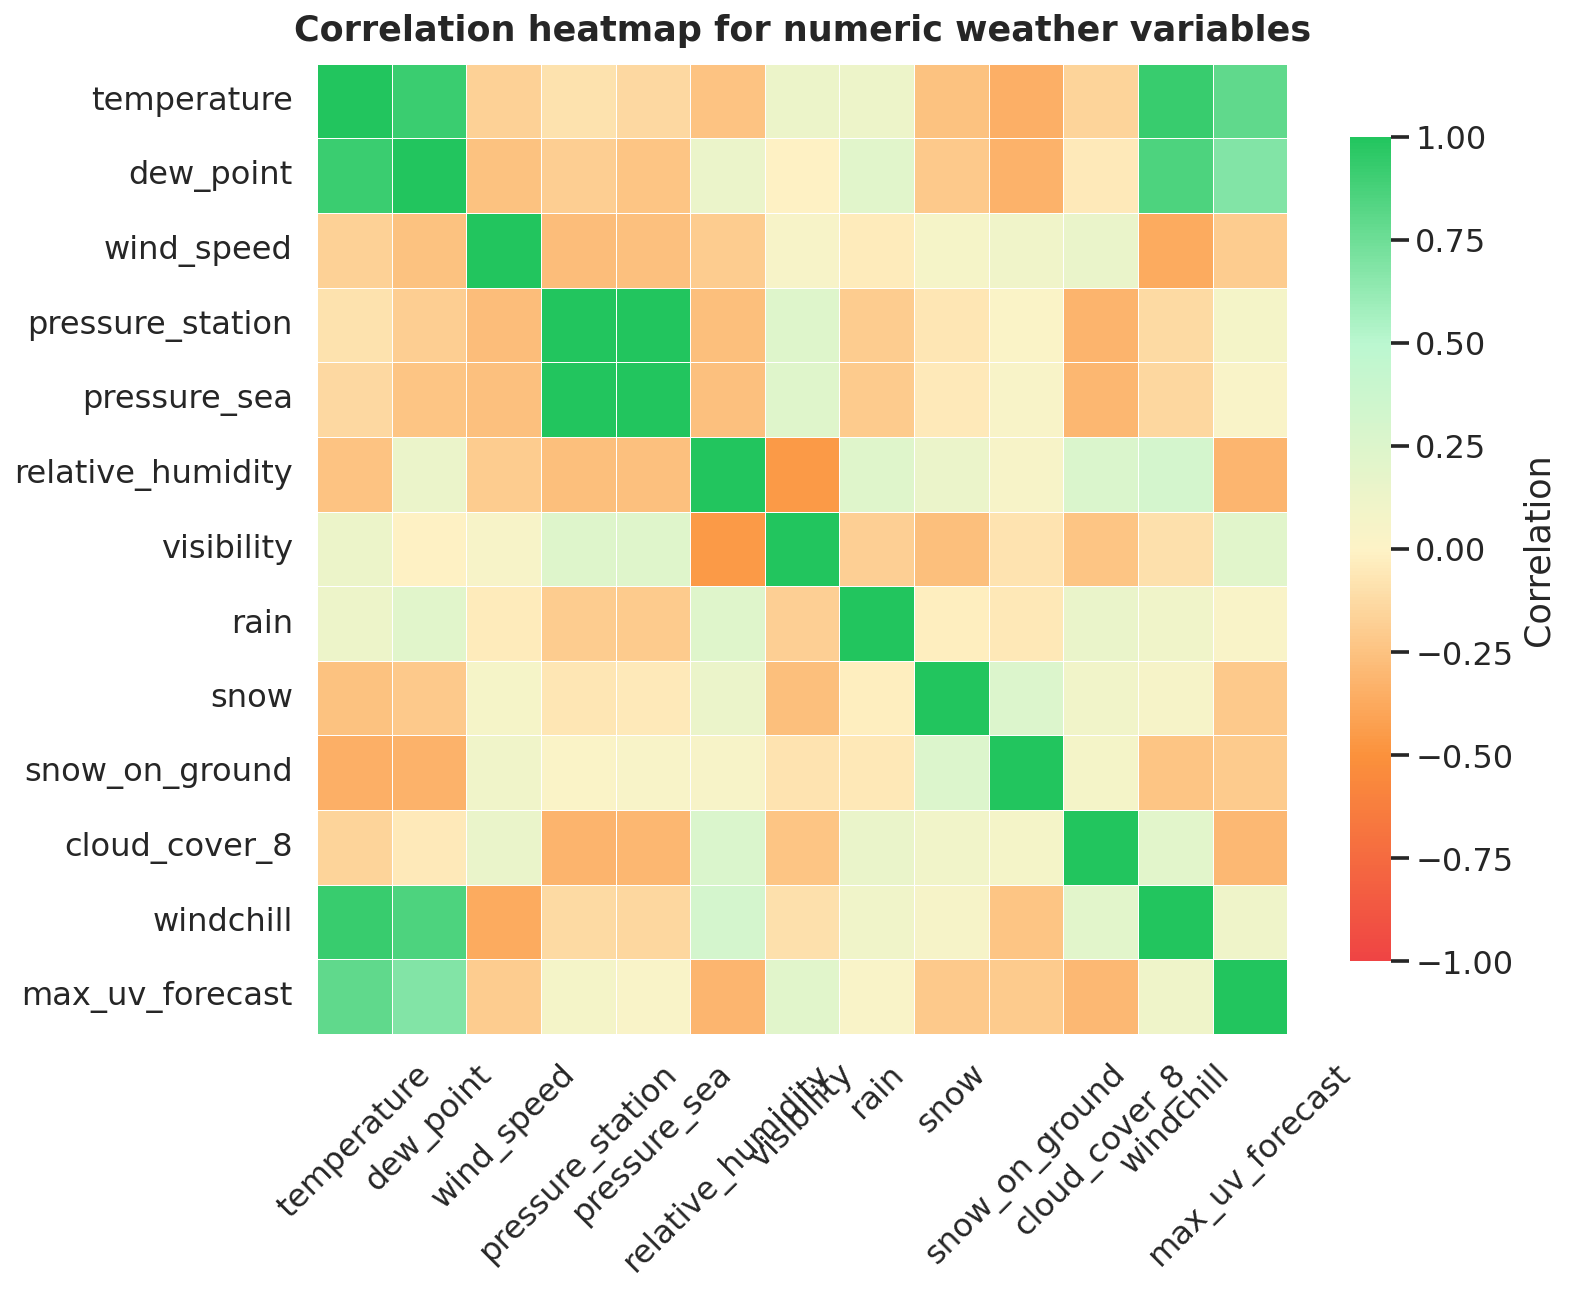

In [61]:
corr_cols = [c for c in numeric_cols if eda_plot[c].notna().sum() > 0]
corr_cols = [c for c in corr_cols if not re.match(r"^Unnamed", str(c).strip(), flags=re.IGNORECASE)]

if len(corr_cols) >= 2:
    corr = eda_plot[corr_cols].corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(11.5, 9))
    sns.heatmap(
        corr,
        cmap=CORR_CMAP,
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.45,
        linecolor="white",
        cbar_kws={"label": "Correlation", "shrink": 0.85},
        ax=ax
    )
    ax.set_title("Correlation heatmap for numeric weather variables", pad=12)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    save_and_show(fig, "weather_correlation_heatmap_styled")
else:
    print("Not enough numeric weather columns for a correlation heatmap.")

## Compact summary table
This table gives a few simple values 

In [62]:
report_stats = {
    "records": len(eda_plot),
    "columns_after_plot_cleaning": len(eda_plot.columns),
    "duplicate_rows": int(df.duplicated().sum()),
    "date_start": eda_plot["weather_datetime"].min() if "weather_datetime" in eda_plot.columns else pd.NaT,
    "date_end": eda_plot["weather_datetime"].max() if "weather_datetime" in eda_plot.columns else pd.NaT,
    "temperature_min": float(eda_plot["temperature"].min()) if "temperature" in eda_plot.columns else np.nan,
    "temperature_max": float(eda_plot["temperature"].max()) if "temperature" in eda_plot.columns else np.nan,
    "mean_visibility": float(eda_plot["visibility"].mean()) if "visibility" in eda_plot.columns else np.nan,
}

report_stats_df = pd.DataFrame(report_stats.items(), columns=["metric", "value"])
display(report_stats_df)

,metric,value
0,records,34097
1,columns_after_plot_cleaning,23
2,duplicate_rows,7791
3,date_start,2023-01-01 00:00:00
4,date_end,2025-12-31 23:00:00
5,temperature_min,-21.8
6,temperature_max,35.8
7,mean_visibility,21893.838345
